In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [2]:
import zipfile

with zipfile.ZipFile('/content/archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

project_path = "/content/drive/MyDrive/breast_cancer_project"
os.makedirs(project_path, exist_ok=True)

In [5]:
!mv /content/Dataset_BUSI_with_GT /content/drive/MyDrive/

In [7]:
import os

# dataset path in Google Drive
directories = "/content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/"

unique_classes = []

for path in os.listdir(directories):
    unique_classes.append(path)

print("Unique classes:\n", unique_classes)

Unique classes:
 ['benign', 'malignant', 'normal']


In [9]:
dataset_path = "/content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT"

In [10]:
import os
import cv2
from pandas import DataFrame

def bounding_box_img(filepath):
    img = cv2.imread(filepath)
    height, width, channels = img.shape

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    contours, _ = cv2.findContours(gray, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    x = y = w = h = None

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

    return (height, width, channels, x, y, w, h)

def extract_label(filepath):
    if 'benign' in filepath:
        return 'benign'
    else:
        return 'malignant'


# dictionary for storing metadata
dict_img = {
    'filename': [],
    'img height': [],
    'img width': [],
    'img channels': [],
    'xmin': [],
    'ymin': [],
    'width': [],
    'height': [],
    'label': []
}


def extract_metadata(file_dir):
    masks = sorted(os.listdir(file_dir))

    for f in masks:
        if 'mask' in f:

            full_path = os.path.join(file_dir, f)

            height, width, channels, x, y, w, h = bounding_box_img(full_path)

            if x is not None:

                dict_img['filename'].append(f)
                dict_img['img height'].append(height)
                dict_img['img width'].append(width)
                dict_img['img channels'].append(channels)
                dict_img['xmin'].append(x)
                dict_img['ymin'].append(y)
                dict_img['width'].append(w)
                dict_img['height'].append(h)
                dict_img['label'].append(extract_label(f))


# run metadata extraction
extract_metadata(dataset_path + "/malignant/")
extract_metadata(dataset_path + "/benign/")


df_img = DataFrame(dict_img)

df_img.head()

,filename,img height,img width,img channels,xmin,ymin,width,height,label
0,malignant (1)_mask.png,598,449,3,8,133,432,271,malignant
1,malignant (10)_mask.png,393,462,3,206,36,100,78,malignant
2,malignant (100)_mask.png,476,557,3,159,70,236,120,malignant
3,malignant (101)_mask.png,559,883,3,237,95,404,279,malignant
4,malignant (102)_mask.png,551,916,3,186,128,396,285,malignant


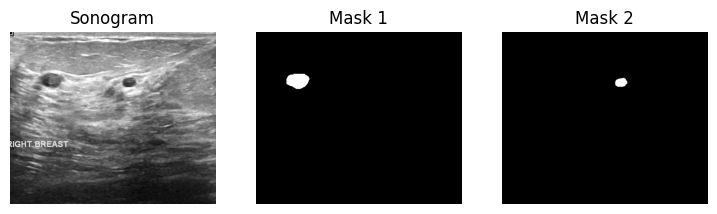

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

# plot sonogram & masks
fig, axs = plt.subplots(1, 3, figsize=(9,3))

image = Image.open(dataset_path + "/benign/benign (4).png")
axs[0].imshow(image)
axs[0].set_title("Sonogram")
axs[0].axis("off")

image = Image.open(dataset_path + "/benign/benign (4)_mask.png")
axs[1].imshow(image)
axs[1].set_title("Mask 1")
axs[1].axis("off")

image = Image.open(dataset_path + "/benign/benign (4)_mask_1.png")
axs[2].imshow(image)
axs[2].set_title("Mask 2")
axs[2].axis("off")

plt.show()

In [13]:
import os
import cv2
from glob import glob

def generate_single_masks(label):

    directory = os.path.join(dataset_path, label)

    # get all mask files
    mask_files = glob(os.path.join(directory, "*_mask*.png"))

    def get_base_name(filepath):
        filename = os.path.basename(filepath)
        return filename.split("_mask")[0]

    # group masks belonging to same image
    mask_groups = {}

    for mask in mask_files:
        base = get_base_name(mask)

        if base not in mask_groups:
            mask_groups[base] = []

        mask_groups[base].append(mask)

    # combine masks
    for base_name, files in mask_groups.items():

        overlayed_mask = None

        for file in files:

            mask = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

            if overlayed_mask is None:
                overlayed_mask = mask
            else:
                overlayed_mask = cv2.add(overlayed_mask, mask)

        output_filename = os.path.join(directory, f"{base_name}_overlayed.png")

        cv2.imwrite(output_filename, overlayed_mask)


# run function
generate_single_masks("benign")
generate_single_masks("malignant")

In [14]:
def generate_normal_masks():

    directory = os.path.join(dataset_path, "normal")

    images = glob(os.path.join(directory, "*.png"))

    for img_path in images:

        if "_mask" not in img_path:

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            empty_mask = img * 0

            base = os.path.basename(img_path).split(".png")[0]

            output = os.path.join(directory, f"{base}_overlayed.png")

            cv2.imwrite(output, empty_mask)


generate_normal_masks()

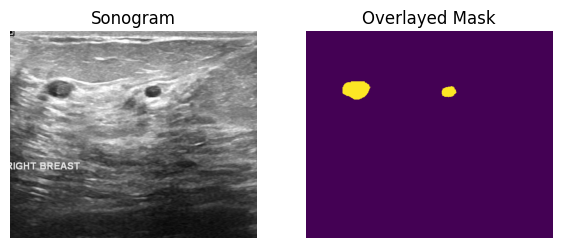

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# plot sonogram & overlayed mask
fig, axs = plt.subplots(1, 2, figsize=(7,3))

image = Image.open(os.path.join(dataset_path, "benign", "benign (4).png"))
axs[0].imshow(image)
axs[0].set_title("Sonogram")
axs[0].axis("off")

image = Image.open(os.path.join(dataset_path, "benign", "benign (4)_overlayed.png"))
axs[1].imshow(image)
axs[1].set_title("Overlayed Mask")
axs[1].axis("off")

plt.show()

In [16]:
directory = os.path.join(dataset_path, "benign")

files_to_delete = glob(os.path.join(directory, "*overlayed*.png"))

# delete each file
for file in files_to_delete:
    try:
        os.remove(file)
        print("Deleted:", file)
    except OSError as e:
        print("Error deleting", file, ":", e)

Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (1)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (10)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (100)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (101)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (102)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (103)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (104)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (105)_overlayed.png
Deleted: /content/drive/MyDrive/breast_cancer_project/Dataset_BUSI_with_GT/benign/benign (106)_overlayed.png
Deleted: /content/driv

In [17]:
from tensorflow.image import resize
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

# load images & convert to NumPy arrays
def load_images(image_paths, img_size=256, mask=False):
    # mask: 1 channel
    # image: 3 channels
    if mask:
        images = np.zeros(shape=(len(image_paths), img_size, img_size, 1))
    else:
        images = np.zeros(shape=(len(image_paths), img_size, img_size, 3))

    for i, image in enumerate(image_paths):
        img = np.round(resize(img_to_array(load_img(image))/255., (img_size, img_size)), 4)
        if mask:
            images[i] = img[:, :, :1]
        else:
            images[i] = img

    return images

In [18]:
from glob import glob
import os

root_path = dataset_path + "/"

unique_classes = ['benign', 'malignant', 'normal']

# collect mask paths
sorted_mask_paths = [
    sorted(glob(os.path.join(root_path, name, "*overlayed.png")))
    for name in unique_classes
]

image_paths = []
mask_paths = []

for class_path in sorted_mask_paths:
    for path in class_path:
        img_path = path.replace("_overlayed", "")
        image_paths.append(img_path)
        mask_paths.append(path)

# convert images & masks
images = load_images(image_paths, img_size=256)
masks = load_images(mask_paths, img_size=256, mask=True)

print("Number of samples:", len(images))
print("Image shape:", images[0].shape, ", Mask shape:", masks[0].shape)

Number of samples: 343
Image shape: (256, 256, 3) , Mask shape: (256, 256, 1)


In [19]:
from sklearn.model_selection import train_test_split

# split dataset into 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.20, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 274
Testing samples: 69


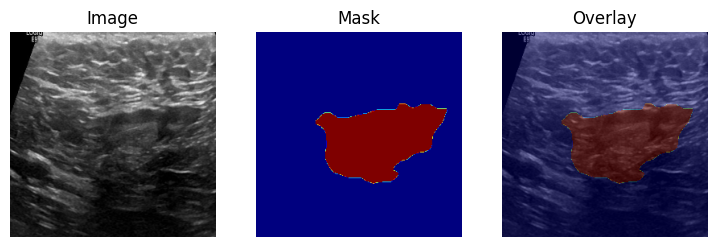

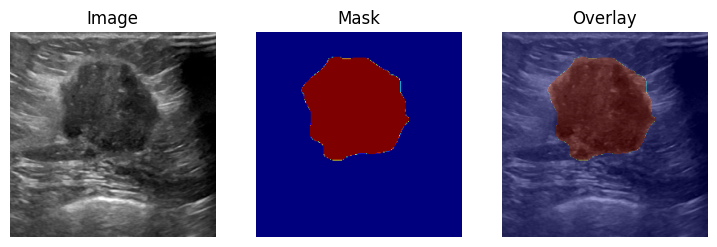

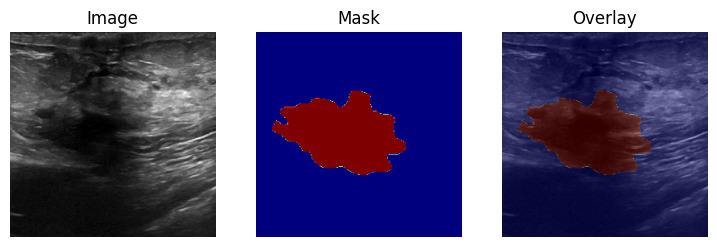

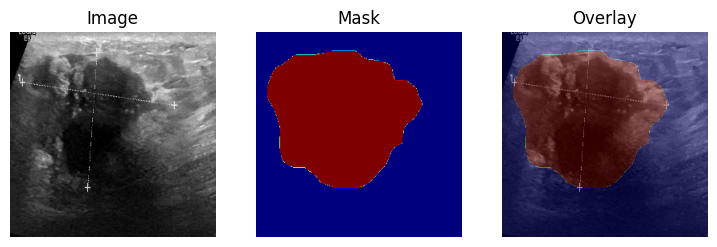

In [22]:
import matplotlib.pyplot as plt

def visualize_dataset(idx):

    fig, axs = plt.subplots(1, 3, figsize=(9,3))

    # original image
    axs[0].imshow(images[idx])
    axs[0].set_title("Image")
    axs[0].axis("off")

    # mask
    axs[1].imshow(masks[idx].squeeze(), cmap="jet")
    axs[1].set_title("Mask")
    axs[1].axis("off")

    # overlay
    axs[2].imshow(images[idx])
    axs[2].imshow(masks[idx].squeeze(), cmap="jet", alpha=0.4)
    axs[2].set_title("Overlay")
    axs[2].axis("off")

    plt.show()

for i in [10, 52, 167, 32]:
    visualize_dataset(i)

In [23]:
from tensorflow.keras.layers import Layer, Input, Conv2D, Dropout, MaxPool2D, UpSampling2D
from tensorflow.keras.layers import concatenate, Add, Multiply, BatchNormalization
from tensorflow.keras.models import Model

# define encoder
class EncoderBlock(Layer):
    def __init__(self, filters, rate, pooling=True, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)

        self.filters = filters
        self.rate = rate
        self.pooling = pooling

        self.c1 = None
        self.drop = None
        self.c2 = None
        self.pool = None if not pooling else MaxPool2D()

    def build(self, input_shape):
        self.c1 = Conv2D(self.filters, kernel_size=3, strides=1, padding='same', activation='relu', kernel_initializer='he_normal')
        self.drop = Dropout(self.rate)
        self.c2 = Conv2D(self.filters, kernel_size=3, strides=1, padding='same', activation='relu', kernel_initializer='he_normal')

        super(EncoderBlock, self).build(input_shape)

    def call(self, X):
        x = self.c1(X)
        x = self.drop(x)
        x = self.c2(x)
        if self.pooling:
            y = self.pool(x)
            return y, x
        else:
            return x

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config, 'filters': self.filters,
            'rate': self.rate, 'pooling': self.pooling
        }

# define decoder
class DecoderBlock(Layer):
    def __init__(self, filters, rate, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)

        self.filters = filters
        self.rate = rate

        self.up = UpSampling2D()
        self.net = EncoderBlock(filters, rate, pooling=False)

    def call(self, X):
        X, skip_X = X
        x = self.up(X)
        c_ = concatenate([x, skip_X])
        x = self.net(c_)
        return x

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, 'filters': self.filters, 'rate': self.rate}

# define attention gate
class AttentionGate(Layer):
    def __init__(self, filters, bn, **kwargs):
        super(AttentionGate, self).__init__(**kwargs)

        self.filters = filters
        self.bn = bn

        self.normal = Conv2D(filters, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal')
        self.down = Conv2D(filters, kernel_size=3, strides=2, padding='same', activation='relu', kernel_initializer='he_normal')
        self.learn = Conv2D(1, kernel_size=1, padding='same', activation='sigmoid')
        self.resample = UpSampling2D()
        self.BN = BatchNormalization()

    def call(self, X):
        X, skip_X = X

        x = self.normal(X)
        skip = self.down(skip_X)
        x = Add()([x, skip])
        x = self.learn(x)
        x = self.resample(x)
        f = Multiply()([x, skip_X])
        if self.bn:
            return self.BN(f)
        else:
            return f

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, 'filters': self.filters, 'bn': self.bn}

In [24]:
def attention_unet_mod(img_height=256, img_width=256, img_channels=3):
    # input layer
    inputs = Input(shape=(img_height, img_width, img_channels))

    # encoder block
    p1, c1 = EncoderBlock(32, rate=0.1, name='Encoder_1')(inputs)
    p2, c2 = EncoderBlock(64, rate=0.1, name='Encoder_2')(p1)
    p3, c3 = EncoderBlock(128, rate=0.2, name='Encoder_3')(p2)
    p4, c4 = EncoderBlock(256, rate=0.2, name='Encoder_4')(p3)

    # encoding
    encoding = EncoderBlock(512, 0.3, pooling=False, name='Encoding')(p4)

    # attention gate + decoder block
    a1 = AttentionGate(256, bn=True, name='Attention_1')([encoding, c4])
    d1 = DecoderBlock(256, rate=0.2, name='Decoder_1')([encoding, a1])

    a2 = AttentionGate(128, bn=True, name='Attention_2')([d1, c3])
    d2 = DecoderBlock(128, rate=0.2, name='Decoder_2')([d1, a2])

    a3 = AttentionGate(64, bn=True, name='Attention_3')([d2, c2])
    d3 = DecoderBlock(64, rate=0.1, name='Decoder_3')([d2, a3])

    a4 = AttentionGate(32, bn=True, name='Attention_4')([d3, c1])
    d4 = DecoderBlock(32, rate=0.1, name='Decoder_4')([d3, a4])

    # output layer
    outputs = Conv2D(1, kernel_size=1, activation='sigmoid', padding='same')(d4)

    model = Model(inputs=[inputs], outputs=[outputs], name='Attention_U-Net')
    return model

att_model = attention_unet_mod()
att_model.summary()

Model: "Attention_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_1           │ [(None, 128, 128, │     10,144 │ input_layer[0][0] │
│ (EncoderBlock)      │ 32), (None, 256,  │            │                   │
│                     │ 256, 32)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_2           │ [(None, 64, 64,   │     55,424 │ Encoder_1[0][0]   │
│ (EncoderBlock)      │ 64), (None, 128,  │            │                   │
│                     │ 128, 64)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_3           │ [(None, 32, 32,   │    221,440 │ Encoder_2[0][0]   │
│ (EncoderBlock)      │ 128), (None, 64,  │            │                   │
│                     │ 64, 128)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_4           │ [(None, 16, 16,   │    885,248 │ Encoder_3[0][0]   │
│ (EncoderBlock)      │ 256), (None, 32,  │            │                   │
│                     │ 32, 256)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoding            │ (None, 16, 16,    │  3,539,968 │ Encoder_4[0][0]   │
│ (EncoderBlock)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_1         │ (None, 32, 32,    │  1,771,265 │ Encoding[0][0],   │
│ (AttentionGate)     │ 256)              │            │ Encoder_4[0][1]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_1           │ (None, 32, 32,    │  2,359,808 │ Encoding[0][0],   │
│ (DecoderBlock)      │ 256)              │            │ Attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_2         │ (None, 64, 64,    │    443,265 │ Decoder_1[0][0],  │
│ (AttentionGate)     │ 128)              │            │ Encoder_3[0][1]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_2           │ (None, 64, 64,    │    590,080 │ Decoder_1[0][0],  │
│ (DecoderBlock)      │ 128)              │            │ Attention_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_3         │ (None, 128, 128,  │    111,041 │ Decoder_2[0][0],  │
│ (AttentionGate)     │ 64)               │            │ Encoder_2[0][1]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_3           │ (None, 128, 128,  │    147,584 │ Decoder_2[0][0],  │
│ (DecoderBlock)      │ 64)               │            │ Attention_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_4         │ (None, 256, 256,  │     27,873 │ Decoder_3[0][0],  │
│ (AttentionGate)     │ 32)               │            │ Encoder_1[0][1]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_4           │ (None, 256, 256,  │     36,928 │ Decoder_3[0][0],  │
│ (DecoderBlock)      │ 32)               │            │ Attention_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 256, 256,  │         33 │ Decoder_4[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 10,200,101 (38.91 MB)

 Trainable params: 10,199,141 (38.91 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping

# compile Attention U-Net model
att_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001, name='adam'),
    metrics=[MeanIoU(num_classes=2, name='IoU'), 'accuracy']
)

# define callbacks
csv_logger = CSVLogger('att_unet_history.txt', append=True, separator=',')

earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=7,
    mode='auto',
    verbose=1,
    restore_best_weights=True
)

# network training
history = att_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=8,
    verbose=1,
    callbacks=[csv_logger, earlystop]
)

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - IoU: 0.4591 - accuracy: 0.9119 - loss: 2.5331 - val_IoU: 0.4408 - val_accuracy: 0.8787 - val_loss: 0.5170
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - IoU: 0.4591 - accuracy: 0.9161 - loss: 0.2545 - val_IoU: 0.4408 - val_accuracy: 0.8787 - val_loss: 0.4452
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step - IoU: 0.4591 - accuracy: 0.9158 - loss: 0.2277 - val_IoU: 0.4408 - val_accuracy: 0.8787 - val_loss: 0.4114
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step - IoU: 0.4591 - accuracy: 0.9169 - loss: 0.2166 - val_IoU: 0.4408 - val_accuracy: 0.8787 - val_loss: 0.4187
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - IoU: 0.4591 - accuracy: 0.9186 - loss: 0.2135 - val_IoU: 0.4408 - val_accuracy: 0.8787 - val_loss: 0.3806
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - IoU: 0.4591 - accuracy: 0.9196 - loss: 0.2020 - val_IoU: 0.4408 - val_accuracy: 0.8791 - val_loss: 0.3029
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s

In [26]:
# save model
att_model.save('attention_unet_mod.keras')

# display training results
df_results = DataFrame(history.history)
df_results.round(4)

,IoU,accuracy,loss,val_IoU,val_accuracy,val_loss
0,0.4591,0.9119,2.5331,0.4408,0.8787,0.5170
1,0.4591,0.9161,0.2545,0.4408,0.8787,0.4452
2,0.4591,0.9158,0.2277,0.4408,0.8787,0.4114
3,0.4591,0.9169,0.2166,0.4408,0.8787,0.4187
4,0.4591,0.9186,0.2135,0.4408,0.8787,0.3806
5,0.4591,0.9196,0.2020,0.4408,0.8791,0.3029
6,0.4591,0.9243,0.1933,0.4408,0.8787,0.3163
7,0.4591,0.9274,0.1874,0.4408,0.8787,0.3987
8,0.4591,0.9307,0.1856,0.4408,0.8789,0.3175
9,0.4591,0.9343,0.1714,0.4408,0.8787,0.3265


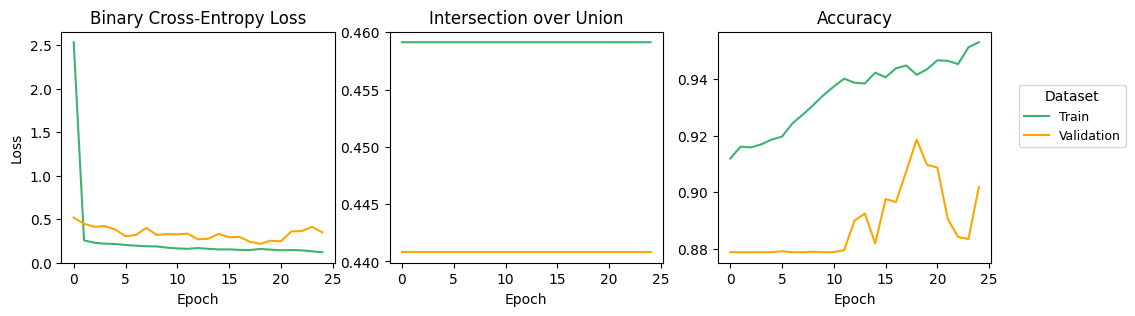

In [27]:
# plot learning curves
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].plot(history.history['loss'], color='mediumseagreen', label='Train')
ax[0].plot(history.history['val_loss'], color='orange', label='Validation')
ax[0].set(title='Binary Cross-Entropy Loss', xlabel='Epoch', ylabel='Loss')

ax[1].plot(history.history['IoU'], color='mediumseagreen', label='Train')
ax[1].plot(history.history['val_IoU'], color='orange', label='Validation')
ax[1].set(title='Intersection over Union', xlabel='Epoch', ylabel=None)

ax[2].plot(history.history['accuracy'], color='mediumseagreen', label='Train')
ax[2].plot(history.history['val_accuracy'], color='orange', label='Validation')
ax[2].set(title='Accuracy', xlabel='Epoch', ylabel=None)
ax[2].legend(loc=(1.1, 0.5), prop={'size': 9}, title='Dataset')

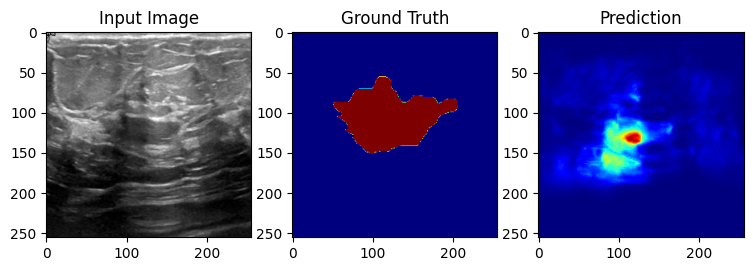

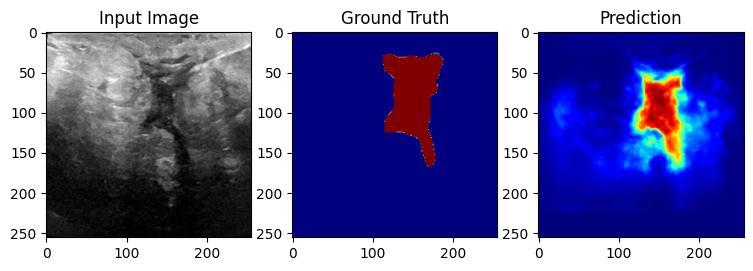

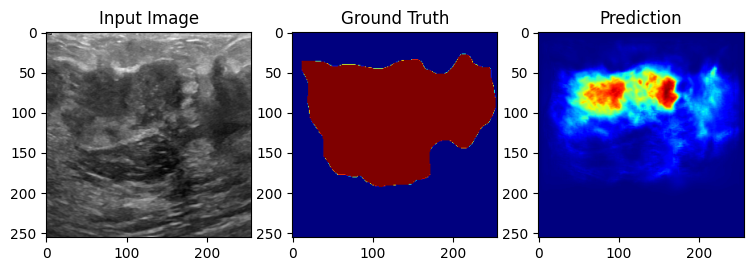

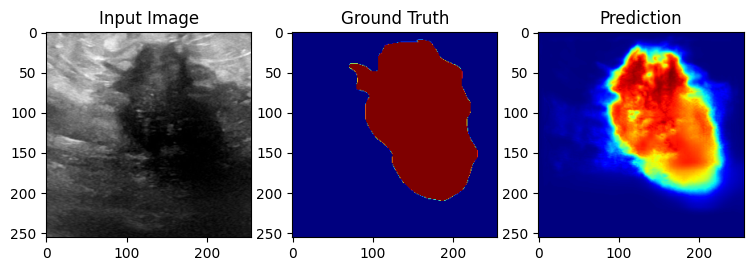

In [28]:
from random import randint

# predict new mask & plot results
def generate_plot():
    # get random image index
    rand_number = randint(0, 150)
    image = images[rand_number]
    mask = masks[rand_number]

    # make prediction
    prediction = att_model.predict(image[np.newaxis, ...], verbose=0)

    # plot: input, mask, prediction
    fig, axs = plt.subplots(1, 3, figsize=(9, 4))

    axs[0].imshow(image)
    axs[0].set(title='Input Image')

    axs[1].imshow(mask, cmap='jet')
    axs[1].set(title='Ground Truth')

    axs[2].imshow(np.squeeze(prediction), cmap='jet')
    axs[2].set(title='Prediction')

    plt.show()

# perform predictions
for _ in range(0, 4):
    generate_plot()

In [30]:
att_model.save("/content/drive/MyDrive/breast_cancer_project/attention_unet_model.keras")

In [31]:
!ls /content/drive/MyDrive/breast_cancer_project

attention_unet_model.keras  Dataset_BUSI_with_GT
